# 0.0 Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import joblib
import matplotlib as plt
import shap

d:\Projetos\vendas\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 0.2 Carregamento dos dados

In [2]:
df = pd.read_csv("../dataset/processado/df_final.csv")

In [3]:
df.describe()

,Unnamed: 0,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Ship Days
count,9986.000000,9986.000000,9975.000000,9986.000000,9986.000000,9986.000000,9986.000000,9986.000000
mean,4997.275786,4998.275786,55261.054837,229.872767,3.789305,0.156258,28.641367,3.958842
std,2884.759278,2884.759278,32041.699892,623.477787,2.225286,0.206499,234.349175,1.747911
min,0.000000,1.000000,1040.000000,0.440000,1.000000,0.000000,-6599.980000,0.000000
25%,2499.250000,2500.250000,23223.000000,17.250000,2.000000,0.000000,1.730000,3.000000
50%,4997.500000,4998.500000,57103.000000,54.380000,3.000000,0.200000,8.640000,4.000000
75%,7494.750000,7495.750000,90008.000000,209.917500,5.000000,0.200000,29.355000,5.000000
max,9993.000000,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.980000,7.000000


# 1.0 Descrição dos dados

## 1.1 Renomear colunas

In [4]:
df.columns = (df.columns
            .str.lower()
            .str.replace(" ","_")
            .str.replace("-", "_")
)

df.columns

Index(['unnamed:_0', 'row_id', 'order_id', 'order_date', 'ship_date',
       'ship_mode', 'customer_id', 'customer_name', 'segment', 'country',
       'city', 'state', 'postal_code', 'region', 'product_id', 'category',
       'sub_category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'person', 'ship_days', 'order_month'],
      dtype='str')

# 1.2 Dimensões

In [5]:
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 9986
Quantidade de colunas: 25


## 1.3 Tipos de Dados

In [6]:
df.dtypes

unnamed:_0         int64
row_id             int64
order_id             str
order_date           str
ship_date            str
ship_mode            str
customer_id          str
customer_name        str
segment              str
country              str
city                 str
state                str
postal_code      float64
region               str
product_id           str
category             str
sub_category         str
product_name         str
sales            float64
quantity           int64
discount         float64
profit           float64
person               str
ship_days          int64
order_month          str
dtype: object

In [7]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

# 1.4 Check NA

In [8]:
df.isna().sum()

unnamed:_0        0
row_id            0
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_id       0
customer_name     0
segment           0
country           0
city              0
state             0
postal_code      11
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
person            0
ship_days         0
order_month       0
dtype: int64

In [9]:
df['postal_code'] = df['postal_code'].astype('Int64')

# 2.0 Seleção das Variáveis

In [10]:
col_cat = ['category', 'sub_category', 'segment', 'state']
col_num = ['sales', 'quantity', 'discount']

In [11]:
df

,unnamed:_0,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,...,category,sub_category,product_name,sales,quantity,discount,profit,person,ship_days,order_month
0,0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,Cassandra Brandow,3,2017-11
1,1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,Cassandra Brandow,3,2017-11
2,2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,Anna Andreadi,4,2017-06
3,3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,Cassandra Brandow,7,2016-10
4,4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,Cassandra Brandow,7,2016-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9981,9989,9990,CA-2015-110422,2015-01-21,2015-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,Furniture,Furnishings,Ultra Door Pull Handle,25.25,3,0.20,4.10,Cassandra Brandow,2,2015-01
9982,9990,9991,CA-2018-121258,2018-02-26,2018-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.96,2,0.00,15.63,Anna Andreadi,5,2018-02
9983,9991,9992,CA-2018-121258,2018-02-26,2018-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,Technology,Phones,Aastra 57i VoIP phone,258.58,2,0.20,19.39,Anna Andreadi,5,2018-02
9984,9992,9993,CA-2018-121258,2018-02-26,2018-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.60,4,0.00,13.32,Anna Andreadi,5,2018-02


# 3.0 Machine Learning

In [12]:
df_result = pd.DataFrame()

## 3.1 Split dataframe

In [13]:
x = df[['category', 'sub_category', 'segment', 'state', 'sales', 'quantity', 'discount']].copy()
y = df['profit'].copy()

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## 3.2 Preprocessor

In [15]:
preprocessor_model = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), col_num),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), col_cat)
    ],
    remainder='passthrough'
)

## 3.3 Linear Regression

In [37]:
lr = LinearRegression(fit_intercept=True)

pipeline = Pipeline([
    ('preprocessor', preprocessor_model),
    ('LinearRegression', lr)
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

result = pd.DataFrame({
    'Modelo': ['LinearRegression'],
    'RMSE': [rmse],
    'MAE': [mae],
    'R2': [r2],
    'parametros': [{'fit_intercept': True}]
})

df_result = pd.concat([df_result, result], ignore_index=True)
df_result

,Modelo,RMSE,MAE,R2,parametros
0,LinearRegression,197.99127,60.0299,0.451044,{'fit_intercept': True}


## 3.4 Decision Tree Regressor

In [38]:
dt = DecisionTreeRegressor()

pipeline = Pipeline([
    ('preprocessor', preprocessor_model),
    ('dt', dt)
])

param_grid = {
    'dt__max_depth': [1, 2, 3],
    'dt__min_samples_split': [2, 3],
    'dt__min_samples_leaf': [2, 3]
}

grid_dt = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3
)

grid_dt.fit(x_train, y_train)

y_pred = grid_dt.predict(x_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

result = pd.DataFrame({
    'Modelo': ['DecisionTreeRegressor'],
    'RMSE': [rmse],
    'MAE': [mae],
    'R2': [r2],
    'parametros': [grid_dt.best_params_]
})

df_result = pd.concat([df_result, result], ignore_index=True)
print(f'Melhores parametros: {grid_dt.best_params_}')
df_result

Melhores parametros: {'dt__max_depth': 3, 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 3}


,Modelo,RMSE,MAE,R2,parametros
0,LinearRegression,197.991270,60.029900,0.451044,{'fit_intercept': True}
1,DecisionTreeRegressor,157.116002,59.259557,0.654311,"{'dt__max_depth': 3, 'dt__min_samples_leaf': 2..."


## 3.5 Random Forest Regressor

In [16]:
rf = RandomForestRegressor()

pipeline = Pipeline([
    ('preprocessor', preprocessor_model),
    ('rf', rf)
])

param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 20, 30],
    'rf__min_samples_split': [2, 3]
}

grid_rf = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3
)

grid_rf.fit(x_train, y_train)

y_pred = grid_rf.predict(x_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

result = pd.DataFrame({
    'Modelo': ['RandomForestRegressor'],
    'RMSE': [rmse],
    'MAE': [mae],
    'R2': [r2],
    'parametros': [grid_rf.best_params_]
})

df_result = pd.concat([df_result, result], ignore_index=True)
print(f"Melhores parametros {grid_rf.best_params_}")
df_result

Melhores parametros {'rf__max_depth': 10, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}


,Modelo,RMSE,MAE,R2,parametros
0,RandomForestRegressor,101.180267,21.449739,0.856637,"{'rf__max_depth': 10, 'rf__min_samples_split':..."


## 3.6 Melhor Modelo

In [17]:
rf = RandomForestRegressor()

pipeline = Pipeline([
    ('preprocessor', preprocessor_model),
    ('rf', rf)
])

pipeline.set_params(**grid_rf.best_params_)

pipeline.fit(x_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['category','sub_category','segment',...,'sales','quantity','discount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis co

In [18]:
joblib.dump(pipeline, '../modelo/modelo.joblib')

['../modelo/modelo.joblib']

In [ ]:
pipeline = joblib.load('../modelo/modelo.joblib')

## 4.0 Shap

In [19]:
preprocessor = pipeline.named_steps['preprocessor']
rf_model = pipeline.named_steps['rf']

In [20]:
x_train_processed = preprocessor.transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [21]:
cols_name = col_num + col_cat
x_test_df = pd.DataFrame(x_test_processed, columns=cols_name)

In [25]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(x_test_df)

shap_values.data = x_test[cols_name].values

In [23]:
shap_values[0]

.values =
array([-50.087203  ,   1.89798131,  17.14515026,   1.61758452,
         3.72777258,  -0.09729872,  -0.35553629])

.base_values =
np.float64(27.444807381906195)

.data =
array([2.78, 1, 0.0, 'Office Supplies', 'Art', 'Home Office',
       'Washington'], dtype=object)

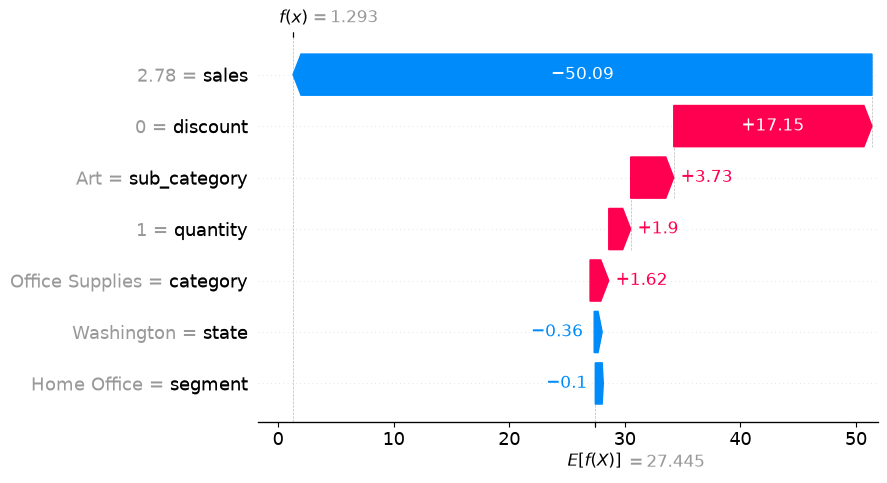

In [26]:
shap.plots.waterfall(shap_values[0])